In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16

In [2]:
dataset_dir = 'images'
img_size = (180, 180)
batch_size = 32
tumor_images = []
no_tumor_images = []

In [3]:
for filename in os.listdir(dataset_dir):
    if filename.lower().startswith('y'):
        tumor_images.append(os.path.join(dataset_dir, filename))
    elif filename.lower().startswith('n'):
        no_tumor_images.append(os.path.join(dataset_dir, filename))

In [4]:
train_tumor_images, val_tumor_images = tumor_images[:int(0.7*len(tumor_images))], tumor_images[int(0.7*len(tumor_images)):]
train_no_tumor_images, val_no_tumor_images = no_tumor_images[:int(0.7*len(no_tumor_images))], no_tumor_images[int(0.7*len(no_tumor_images)):]

In [5]:
def load_image(file):
    img = tf.io.read_file(file)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = img / 255.0
    return img

In [6]:
train_images = [load_image(file) for file in train_tumor_images + train_no_tumor_images]
train_labels = [1] * len(train_tumor_images) + [0] * len(train_no_tumor_images)
validation_images = [load_image(file) for file in val_tumor_images + val_no_tumor_images]
validation_labels = [1] * len(val_tumor_images) + [0] * len(val_no_tumor_images)

In [7]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator()

train_dataset = train_datagen.flow(
    np.array(train_images),
    np.array(train_labels),
    batch_size=batch_size
)

validation_dataset = validation_datagen.flow(
    np.array(validation_images),
    np.array(validation_labels),
    batch_size=batch_size
)

In [8]:
# CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(180, 180, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_dataset, epochs=10, validation_data=validation_dataset)

C:\Users\pranj\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


C:\Users\pranj\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 526ms/step - accuracy: 0.7473 - loss: 0.6608 - val_accuracy: 0.7581 - val_loss: 0.5011
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 478ms/step - accuracy: 0.7929 - loss: 0.5268 - val_accuracy: 0.7581 - val_loss: 0.4939
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 600ms/step - accuracy: 0.7586 - loss: 0.5063 - val_accuracy: 0.7581 - val_loss: 0.4909
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 541ms/step - accuracy: 0.7309 - loss: 0.5097 - val_accuracy: 0.7581 - val_loss: 0.5064
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 523ms/step - accuracy: 0.8106 - loss: 0.4416 - val_accuracy: 0.7581 - val_loss: 0.4950
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 494ms/step - accuracy: 0.7642 - loss: 0.4777 - val_accuracy: 0.7581 - val_loss: 0.5321
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 499ms/step - accuracy: 0.7930 - loss: 0.5001 - val_accuracy: 0.7581 - val_loss: 0.4818
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 554ms/step - accuracy: 0.7468 - loss: 0.5038 - val_accuracy: 0.7581 - val_loss: 0.4827
Epo

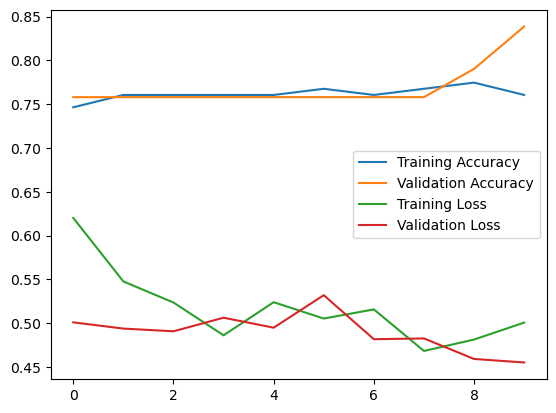

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Prediction: [[0.9548318]]


In [9]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

image_path = os.path.join(os.getcwd(), 'images', 'Y10.jpg')
image_string = tf.io.read_file(image_path)
new_image = tf.image.decode_jpeg(image_string, channels=3)
new_image = tf.image.resize(new_image, img_size)
new_image = new_image / 255.0
new_image = new_image[tf.newaxis, ...]

prediction = model.predict(new_image)
print('Prediction:', prediction)

In [10]:
dataset_dir = 'images'
img_size = (180, 180)
batch_size = 32

In [11]:
tumor_images = []
no_tumor_images = []

for filename in os.listdir(dataset_dir):
    if filename.lower().startswith('y'):
        tumor_images.append(os.path.join(dataset_dir, filename))
    elif filename.lower().startswith('n'):
        no_tumor_images.append(os.path.join(dataset_dir, filename))

train_tumor_images = tumor_images[:int(0.8 * len(tumor_images))]
val_tumor_images = tumor_images[int(0.8 * len(tumor_images)):]
train_no_tumor_images = no_tumor_images[:int(0.8 * len(no_tumor_images))]
val_no_tumor_images = no_tumor_images[int(0.8 * len(no_tumor_images)):]

In [12]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator()

train_dataset = train_datagen.flow(
    np.array(train_images),
    np.array(train_labels),
    batch_size=batch_size
)

validation_dataset = validation_datagen.flow(
    np.array(validation_images),
    np.array(validation_labels),
    batch_size=batch_size
)

### AlexNet Model

In [13]:
alexnet_model = Sequential([
    Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=(180, 180, 3)),
    MaxPooling2D((3, 3), strides=2),
    Conv2D(256, (5, 5), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=2),
    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=2),
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

alexnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
alexnet_history = alexnet_model.fit(train_dataset, epochs=10, validation_data=validation_dataset)

C:\Users\pranj\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5921 - loss: 0.7885 - val_accuracy: 0.7581 - val_loss: 0.8558
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 984ms/step - accuracy: 0.7456 - loss: 0.7222 - val_accuracy: 0.7581 - val_loss: 0.6105
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7683 - loss: 0.5766 - val_accuracy: 0.7581 - val_loss: 0.5527
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7480 - loss: 0.5603 - val_accuracy: 0.7581 - val_loss: 0.5516
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7668 - loss: 0.5449 - val_accuracy: 0.7581 - val_loss: 0.5616
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7586 - loss: 0.5425 - val_accuracy: 0.7581 - val_loss: 0.5774
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7454 - loss: 0.5838 - val_accuracy: 0.7581 - val_loss: 0.5649
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7286 - loss: 0.5866 - val_accuracy: 0.7581 - val_loss: 0.5533
Epoch 9/10
5/

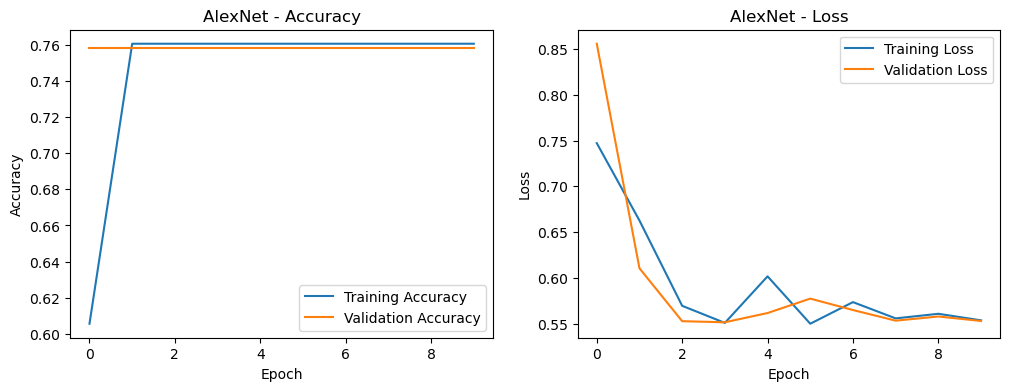

In [14]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))

    # Plot 1
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot 2
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_history(alexnet_history, 'AlexNet')

### VGG16

In [15]:
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(180, 180, 3))
for layer in vgg16_base.layers:
    layer.trainable = False

vgg16_model = Sequential([
    vgg16_base,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

vgg16_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
vgg16_history = vgg16_model.fit(train_dataset, epochs=10, validation_data=validation_dataset)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step - accuracy: 0.5929 - loss: 2.3551 - val_accuracy: 0.7581 - val_loss: 0.7729
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 28s 6s/step - accuracy: 0.6697 - loss: 0.7186 - val_accuracy: 0.7742 - val_loss: 0.4641
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.7140 - loss: 0.6636 - val_accuracy: 0.7581 - val_loss: 0.4600
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.7784 - loss: 0.5030 - val_accuracy: 0.7419 - val_loss: 0.5739
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.7592 - loss: 0.4913 - val_accuracy: 0.7903 - val_loss: 0.4043
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.7179 - loss: 0.5517 - val_accuracy: 0.7742 - val_loss: 0.3874
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.7935 - loss: 0.4438 - val_accuracy: 0.7742 - val_loss: 0.3997
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step - accuracy: 0.7863 - loss: 0.4781 - val_accuracy: 0.9194 - val_loss: 0.4357
Epoch 9/

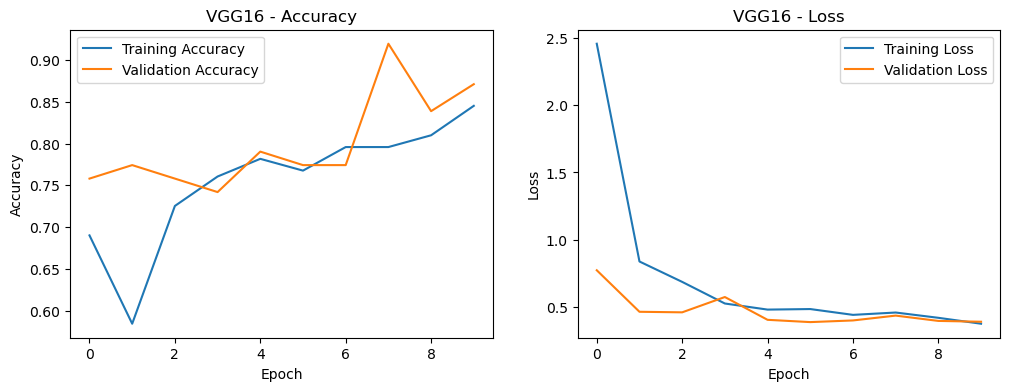

In [16]:
plot_training_history(vgg16_history, 'VGG16')

### Augmentation

In [17]:
def display_augmented_images(datagen, image_path):
    if not os.path.exists(image_path):
        print(f"File not found: {image_path}")
        return

    image_string = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.resize(image, img_size)
    image = image / 255.0
    image = image[tf.newaxis, ...]

    augmented_images = datagen.flow(image, batch_size=1)

    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        batch = next(augmented_images)
        augmented_image = batch[0]
        plt.imshow(augmented_image)
        plt.axis('off')

    plt.show()

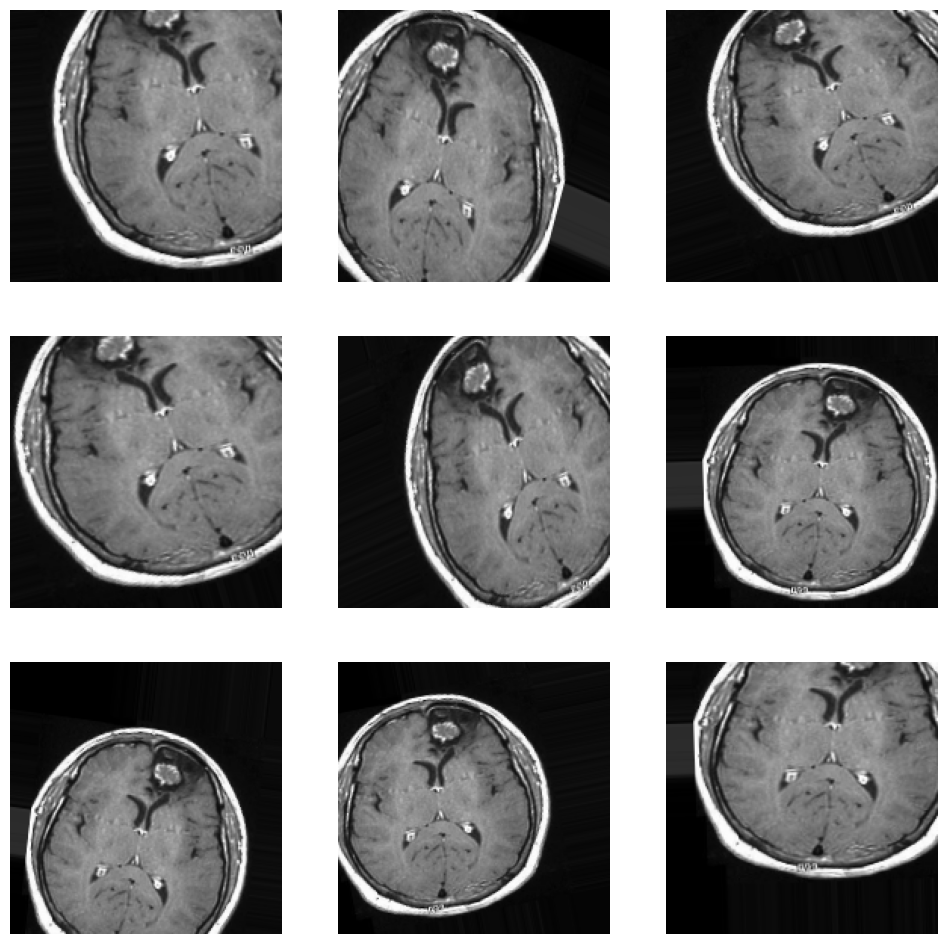

In [18]:
image_to_display = 'Y12.jpg'

if image_to_display:
    display_augmented_images(train_datagen, os.path.join(dataset_dir, image_to_display))
else:
    print("No tumor images found in the dataset.")

In [19]:
image_path = os.path.join(os.getcwd(), 'images', 'N11.jpg')
image_string = tf.io.read_file(image_path)
new_image = tf.image.decode_jpeg(image_string, channels=3)
new_image = tf.image.resize(new_image, img_size)
new_image = new_image / 255.0
new_image = new_image[tf.newaxis, ...]

vgg16_prediction = vgg16_model.predict(new_image)
alexnet_prediction = alexnet_model.predict(new_image)

print('VGG16 Prediction:', vgg16_prediction)
print('AlexNet Prediction:', alexnet_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
VGG16 Prediction: [[0.65607154]]
AlexNet Prediction: [[0.75484836]]
